**Importing all the important libraries**

In [4]:
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import  RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import pickle

parent_dir = str(Path().resolve().parent)
if parent_dir not in sys.path:
    sys.path.insert(0,parent_dir)

from mediapipe_handler.mediapipe_handler import MediaPipeHandler

current_dir = os.getcwd()

**Workflow**
1. Loading Training and Testing Datasets
2. Add Label string values
3. Looking at workout distributions
4. Preprocessing
5. Feature Engineering
6. Train Random Forest with hyperparameters [with and without feature engineering]
7. Train Neural Network with hyperparameters [with and without feature engineering]
8. Train SVM with hyperparameters [with and without feature engineering]
9. Compare model performance in terms of SPEED,ACCURACY,PERCISION,RECALL,F1-SCORE
10. Do the same process but with SMOTE to handle imbalance classes, then compare accuracy

**1. Loading Training and Testing Datasets**

In [5]:
mediapipe_model = MediaPipeHandler()

training_dataset=mediapipe_model.read_csv_to_pd(current_dir + "/../../data/datasets/train.csv")[:40000]
testing_dataset=mediapipe_model.read_csv_to_pd(current_dir + "/../../data/datasets/test.csv")

I0000 00:00:1759195382.932531 38808636 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1759195383.026368 38858934 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759195383.043936 38858934 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [6]:
training_dataset

,Unnamed: 0,image,label,muscle group,left_shoulder,right_shoulder,left_elbow,right_elbow,left_wrist,right_wrist,left_hip,right_hip,left_knee,right_knee,left_ankle,right_ankle
0,0,<PIL.JpegImagePlugin.JpegImageFile image mode=...,9,1,"[0.6279079, 0.32339512, -0.06061802]","[0.47960379, 0.37588128, 0.03317507]","[0.64011523, 0.45552775, -0.12237725]","[0.40441692, 0.45420197, 0.06196359]","[0.69860009, 0.54521748, -0.42476123]","[0.3504715, 0.53548855, -0.16950618]","[0.56546664, 0.66270596, -0.03197554]","[0.51792681, 0.65376824, -0.0079275]","[0.56493276, 0.87819928, -0.09594794]","[0.50829606, 0.86941437, -0.05506779]","[0.58834489, 1.07244761, 0.18128562]","[0.47170629, 1.03338206, 0.24772888]"
1,1,<PIL.JpegImagePlugin.JpegImageFile image mode=...,12,4,"[0.65504223, 0.69958192, 0.18758897]","[0.67093658, 0.75491905, -0.2163475]","[0.64890867, 0.82727271, 0.23788658]","[0.67794418, 0.9133994, -0.19132842]","[0.70936406, 0.85877979, 0.19138378]","[0.72769916, 0.88399738, -0.01097734]","[0.48021358, 0.70048791, 0.13355146]","[0.47575095, 0.733459, -0.1335454]","[0.42844069, 0.75284237, 0.27153638]","[0.35944694, 0.78382492, -0.02896746]","[0.31512383, 0.79670227, 0.39159593]","[0.21156754, 0.7983737, 0.03992291]"
2,2,<PIL.JpegImagePlugin.JpegImageFile image mode=...,11,4,"[0.53982484, 0.41680562, -0.13693021]","[0.47483376, 0.41094902, -0.12709852]","[0.57757056, 0.33325151, -0.19398631]","[0.4345724, 0.33275574, -0.17942721]","[0.59011853, 0.23534696, -0.27659982]","[0.43355563, 0.23530559, -0.27939045]","[0.51256299, 0.62060726, -0.00525387]","[0.47625652, 0.6167044, 0.005369]","[0.50218821, 0.74445051, -0.0603612]","[0.4814699, 0.74424905, -0.07409328]","[0.50008607, 0.89680576, 0.01071745]","[0.48592651, 0.90328681, -0.01995635]"
3,3,<PIL.JpegImagePlugin.JpegImageFile image mode=...,14,2,"[0.57072961, 0.62977474, -0.81340833]","[0.40396473, 0.69569516, -0.85307688]","[0.62231527, 0.637308, -0.66569775]","[0.27208328, 0.77984519, -0.75917523]","[0.68162807, 0.84560763, -0.81759362]","[0.29851767, 0.89064747, -0.85210252]","[0.45409909, 0.59270298, 0.01397728]","[0.40430856, 0.6117717, -0.01385183]","[0.4724367, 0.56369885, 0.59090414]","[0.36899394, 0.64755791, 0.618294]","[0.39619607, 0.58656132, 1.36535978]","[0.35447904, 0.59341902, 1.32948148]"
4,4,<PIL.JpegImagePlugin.JpegImageFile image mode=...,21,5,"[0.70394552, 0.39237416, 0.09501911]","[0.62393188, 0.35562551, -0.32122636]","[0.7003023, 0.54802758, 0.06991863]","[0.58862585, 0.55264509, -0.31137052]","[0.76701444, 0.52059174, -0.1783971]","[0.7096169, 0.50729507, -0.17560914]","[0.6039139, 0.67096514, 0.11409215]","[0.56307244, 0.66146231, -0.11368777]","[0.5716424, 0.84088224, 0.28283474]","[0.54704219, 0.84590471, 0.09003581]","[0.5352155, 0.95360124, 0.62651646]","[0.55670625, 1.09988347, 0.71261572]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,39995,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,2,"[0.52760547, 0.43788663, 0.38513213]","[0.50129014, 0.41306007, 0.28855857]","[0.55944747, 0.44333586, 0.40332714]","[0.41851209, 0.0985438, 0.18164979]","[0.59283024, 0.45075855, 0.42372814]","[0.44990033, 0.3073943, 0.41429055]","[0.60936397, 0.44469491, 0.033134]","[0.59165776, 0.44249344, -0.03321873]","[0.68888986, 0.53126478, -0.07206885]","[0.63009501, 0.57036471, -0.19184336]","[0.65490371, 0.61354995, -0.00848129]","[0.59675831, 0.68319726, -0.22454545]"
39996,39996,<PIL.JpegImagePlugin.JpegImageFile image mode=...,1,2,"[0.57458001, 0.57391161, 0.55442286]","[0.44458318, 0.64730555, 0.37012869]","[0.6173203, 0.43785197, 0.57965744]","[0.38218397, 0.5259102, 0.28001416]","[0.60593825, 0.27342061, 0.68003658]","[0.38010997, 0.34080991, 0.48879361]","[0.67268425, 0.75329977, 0.06525257]","[0.60202664, 0.8042804, -0.06552006]","[0.85190523, 0.83153319, -0.23386712]","[0.75367826, 0.85944295, -0.34387952]","[0.84443438, 1.03960872, -0.10013493]","[0.82063627, 1.0843519, -0.27709654]"
39997,39997,<PIL.JpegImagePlugin.JpegImageFil

In [7]:
training_dataset['left_ankle']

0         [0.58834489, 1.07244761, 0.18128562]
1         [0.31512383, 0.79670227, 0.39159593]
2         [0.50008607, 0.89680576, 0.01071745]
3         [0.39619607, 0.58656132, 1.36535978]
4          [0.5352155, 0.95360124, 0.62651646]
                         ...                  
39995    [0.65490371, 0.61354995, -0.00848129]
39996    [0.84443438, 1.03960872, -0.10013493]
39997     [0.67537689, 1.66892004, 0.21393371]
39998      [0.62045938, 0.84493077, 0.4144235]
39999      [0.5276825, 1.17309577, 0.39414152]
Name: left_ankle, Length: 40000, dtype: object

**3. Looking at Workout Distribution**

In [8]:
Workout_labels=training_dataset['muscle group'].unique()

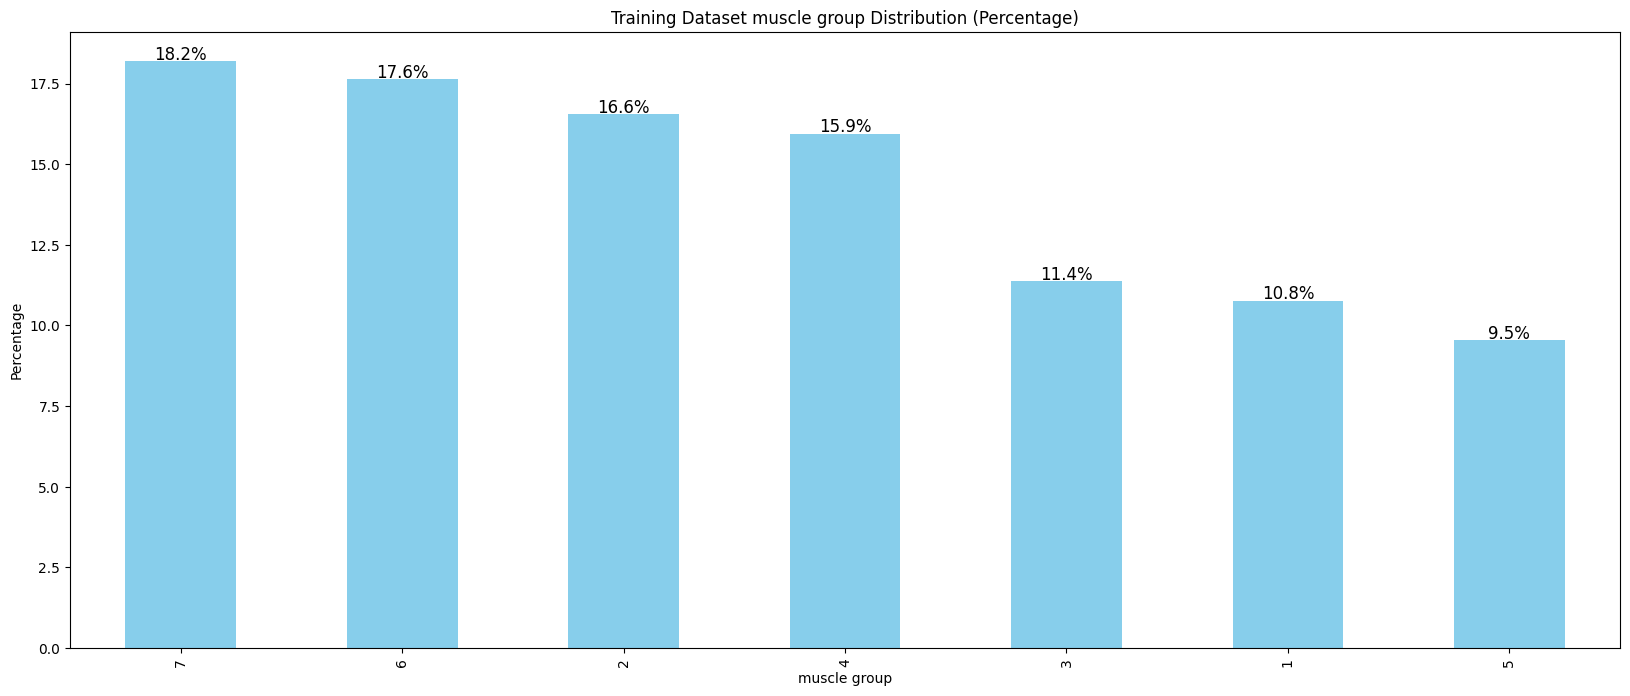

In [9]:
def display_class_distribution(classes):    
    plt.figure(figsize=(20,8))
    value_counts = classes.value_counts()
    percentages = value_counts / value_counts.sum() * 100

    # Plot
    ax = percentages.plot(kind='bar', color='skyblue')

    # Add percentage text on each bar
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

    plt.title('Training Dataset muscle group Distribution (Percentage)')
    plt.ylabel('Percentage')
    plt.show()
display_class_distribution(training_dataset['muscle group'])

**4. Preprocessing**

**We have to make sure that we get right of Unamed 0: column, as it just contains numerical index not very useful, might lead to overfitting if it is left**
- Get rid of Unnamed 0:
- Get rid of image
- Get rid of muscle group
- split each feature into x,y,z components, then remove that original feature


In [10]:
"""
Removes original feature and splits it into x,y,z components

"""
def Preprocess_data(dataframe,columns_to_flatten):
    final_df=dataframe.copy()
    # Expanding each column into 3 separate columns (x, y, z) and appending it to the final dataframe.
    for column in columns_to_flatten:
        # print(np.vstack(dataframe[column]).astype(float))
        expanded_df=pd.DataFrame(np.vstack(dataframe[column]).astype(float), 
                           columns=[column+'_x', column+'_y', column+'_z'],
                           index=dataframe.index)
        new_df = pd.concat([dataframe.drop(column, axis=1), expanded_df], axis=1)
        for new_column in new_df.columns:
            final_df[new_column] = new_df[new_column]

    return final_df.drop(columns=columns_to_flatten,axis=1)

"""
Splits dataset into X_train,y_train or X_test,y_test, if you give it training dataset then X_train and y_train

"""
def Return_X_y(dataframe,columns_to_delete):
    X=dataframe.drop(columns=columns_to_delete)
    y=dataframe['muscle group']
    return X,y

In [11]:
features_to_split=['left_shoulder',
       'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist',
       'right_wrist', 'left_hip', 'right_hip', 'left_knee',
       'right_knee', 'left_ankle', 'right_ankle']

training_dataset_preprocessed=Preprocess_data(training_dataset,features_to_split)
X_train, y_train = Return_X_y(training_dataset_preprocessed,['label','muscle group','image','Unnamed: 0'])


testing_dataset_preprocessed=Preprocess_data(testing_dataset,features_to_split)
X_test, y_test = Return_X_y(testing_dataset_preprocessed,['label','muscle group','image','Unnamed: 0'])

In [12]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
X_test, y_test = smote.fit_resample(X_test, y_test)

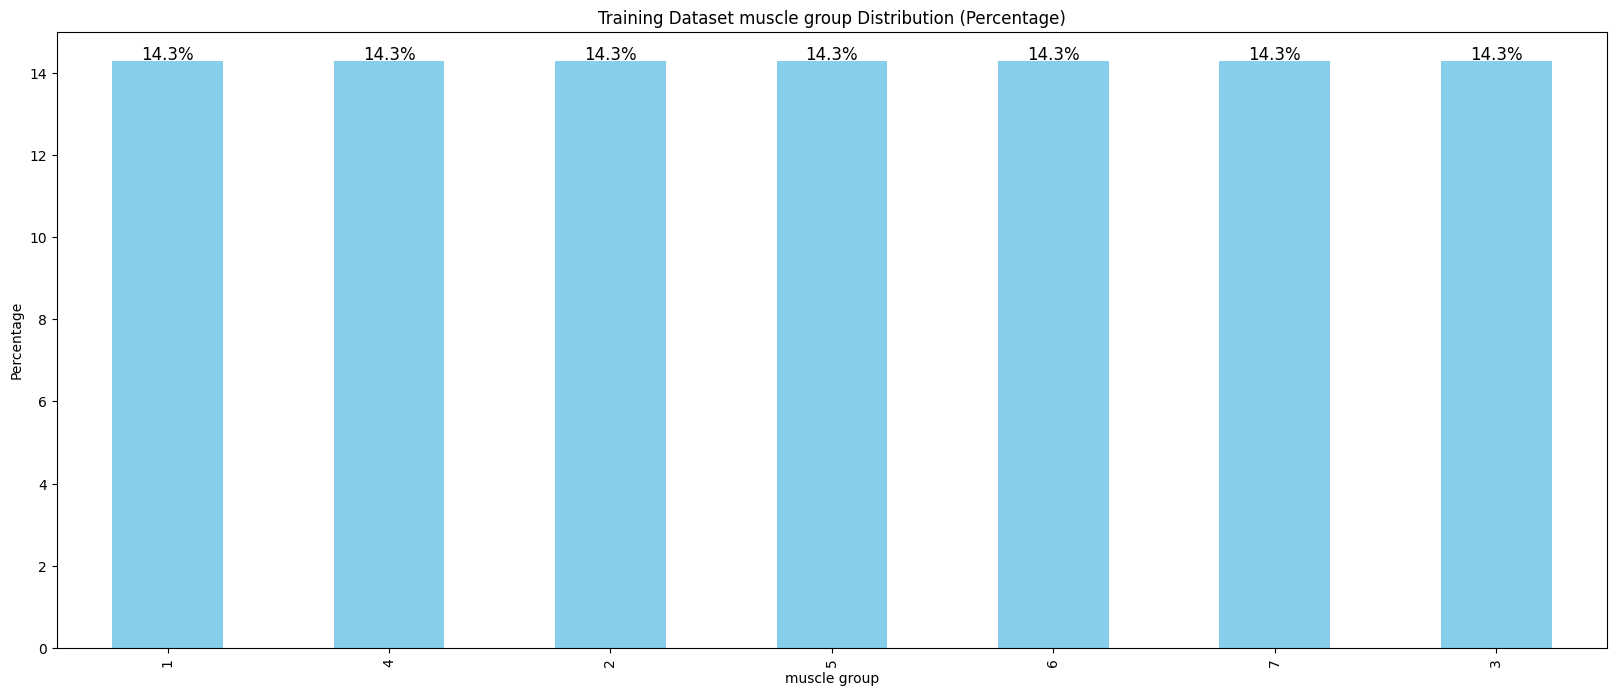

In [13]:
display_class_distribution(y_train)

In [14]:
print("X_train Shape",X_train.shape)

print("y_train Shape",y_train.shape)

print("X_test Shape",X_test.shape)

print("y_test Shape",y_test.shape)

X_train Shape (50939, 36)
y_train Shape (50939,)
X_test Shape (14112, 36)
y_test Shape (14112,)


**66 Features is all the features**

**5. Feature Engineering**

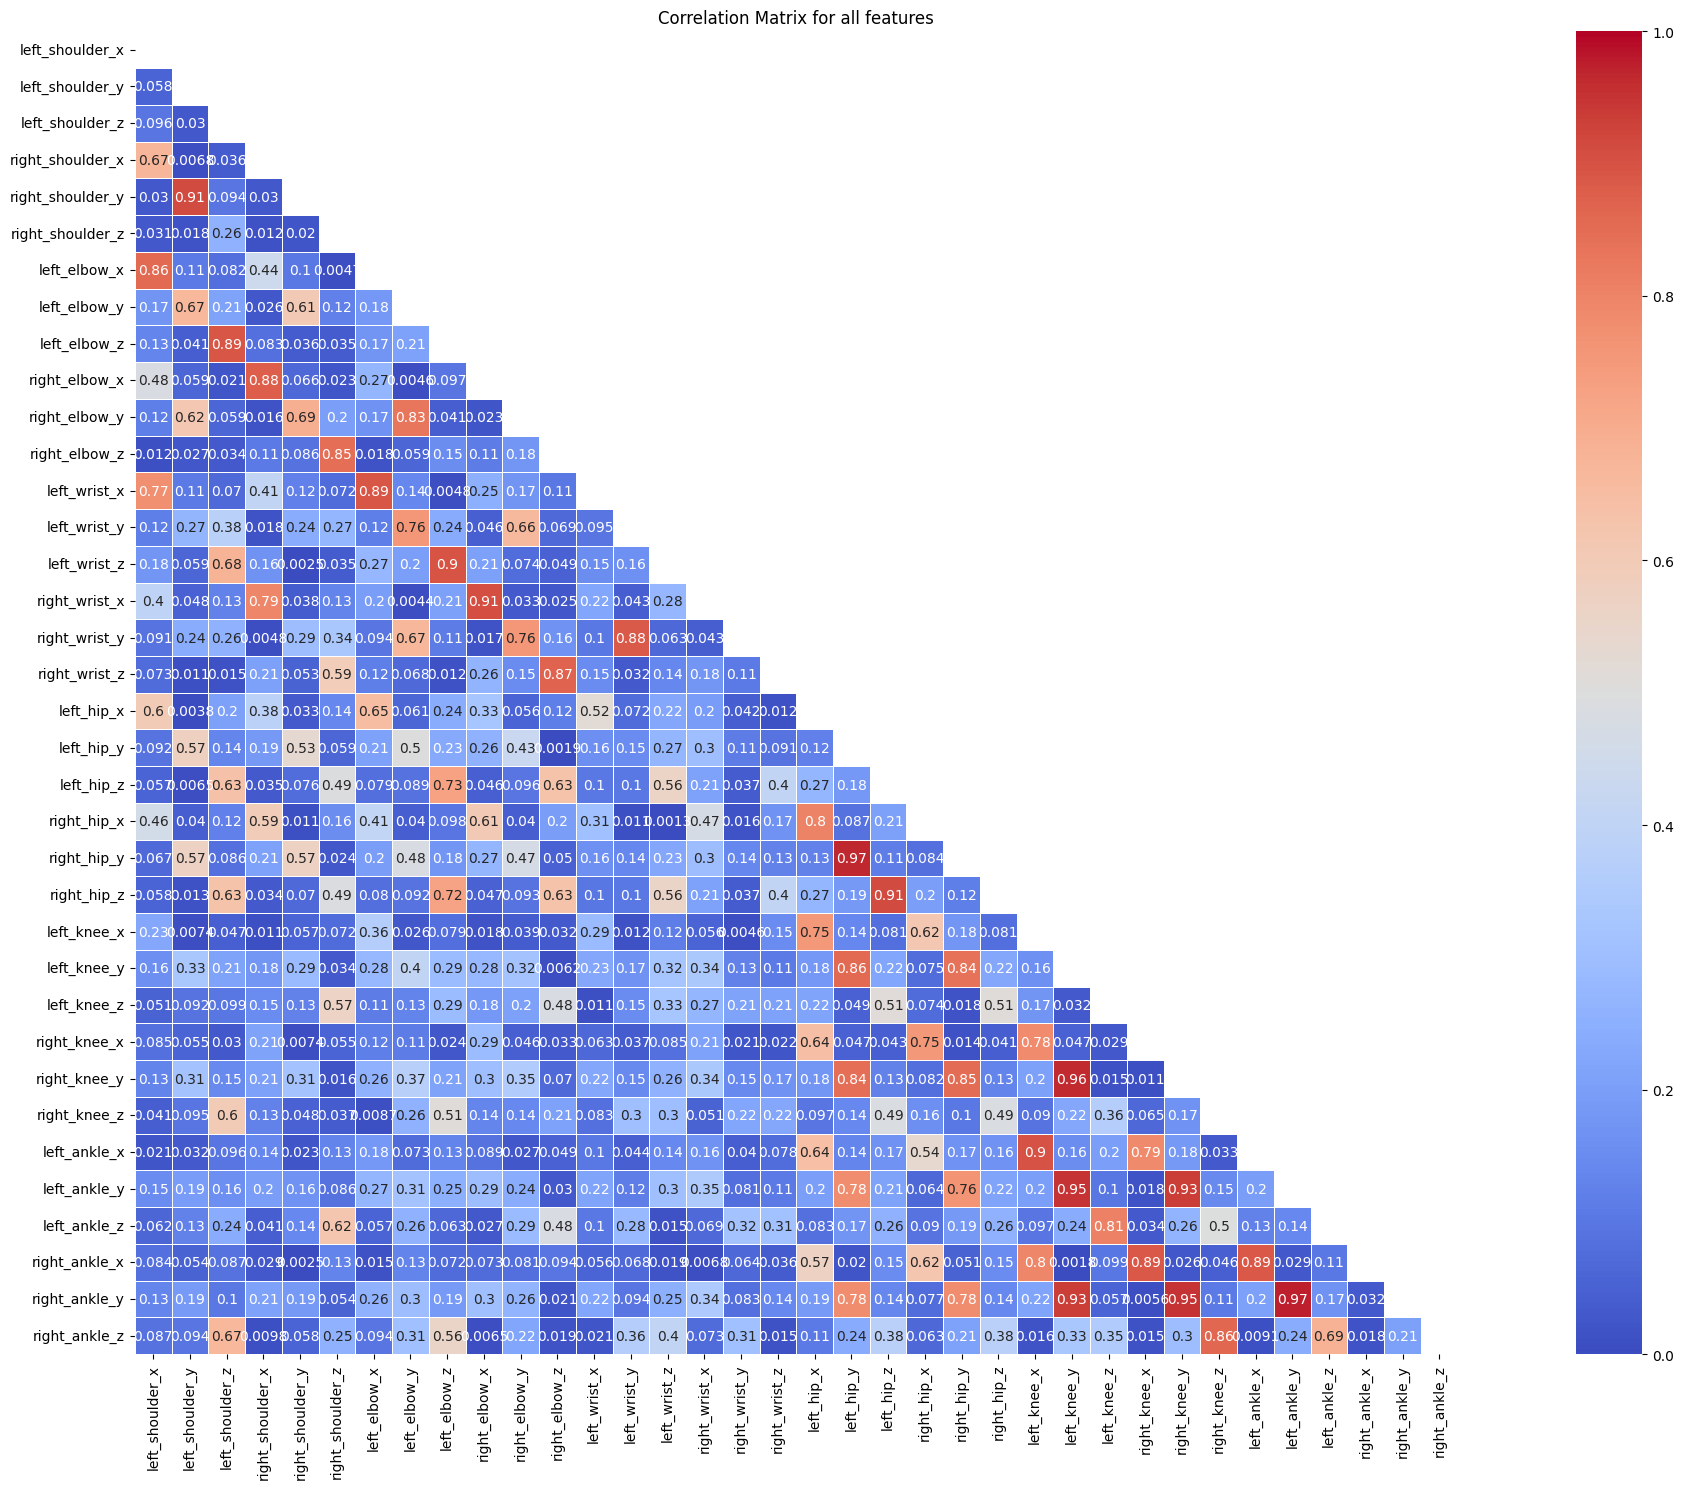

In [15]:
corr_matrix = X_train.corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(24, 15))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', 
            vmax=1.0, vmin=0, center=0.5,
            square=True, linewidths=.5, annot=True).set(title='Correlation Matrix for all features')
plt.tight_layout()
plt.show()

**Features that are highly correlated , one of them should be removed**
- it is better to remove the one that is the least correlated with y_target

In [16]:
correlation_threshold = 0.8
columns_to_drop = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > correlation_threshold:
            columns_to_drop.append(corr_matrix.columns[j])
            print(f"High Correlation between {corr_matrix.columns[i]} and {corr_matrix.columns[j]} --> {corr_matrix.iloc[i, j]:.2f}")

columns_to_drop = list(set(columns_to_drop))
print(f"Columns to drop: {columns_to_drop}")
print(f"number of columns to drop: {len(columns_to_drop)}")

High Correlation between left_shoulder_x and left_elbow_x --> 0.86
High Correlation between left_shoulder_y and right_shoulder_y --> 0.91
High Correlation between left_shoulder_z and left_elbow_z --> 0.89
High Correlation between right_shoulder_x and right_elbow_x --> 0.88
High Correlation between right_shoulder_z and right_elbow_z --> 0.85
High Correlation between left_elbow_x and left_wrist_x --> 0.89
High Correlation between left_elbow_y and right_elbow_y --> 0.83
High Correlation between left_elbow_z and left_wrist_z --> 0.90
High Correlation between right_elbow_x and right_wrist_x --> 0.91
High Correlation between right_elbow_z and right_wrist_z --> 0.87
High Correlation between left_wrist_y and right_wrist_y --> 0.88
High Correlation between left_hip_x and right_hip_x --> 0.80
High Correlation between left_hip_y and right_hip_y --> 0.97
High Correlation between left_hip_y and left_knee_y --> 0.86
High Correlation between left_hip_y and right_knee_y --> 0.84
High Correlation betwe

In [17]:
print(f"Columns to drop: {columns_to_drop}")


Columns to drop: ['right_hip_z', 'right_wrist_x', 'left_ankle_y', 'left_elbow_x', 'right_shoulder_y', 'right_hip_x', 'right_knee_y', 'right_wrist_y', 'left_elbow_z', 'right_ankle_z', 'left_wrist_z', 'left_ankle_z', 'right_ankle_x', 'right_elbow_x', 'right_ankle_y', 'right_elbow_y', 'left_wrist_x', 'right_hip_y', 'right_elbow_z', 'left_knee_y', 'left_ankle_x', 'right_wrist_z']


**53 Columns to drop**

In [18]:
X_train_feature_eng=X_train.drop(columns=columns_to_drop)
X_test_feature_eng=X_test.drop(columns=columns_to_drop)

In [19]:
X_train_feature_eng

,left_shoulder_x,left_shoulder_y,left_shoulder_z,right_shoulder_x,right_shoulder_z,left_elbow_y,left_wrist_y,left_hip_x,left_hip_y,left_hip_z,left_knee_x,left_knee_z,right_knee_x,right_knee_z
0,0.627908,0.323395,-0.060618,0.479604,0.033175,0.455528,0.545217,0.565467,0.662706,-0.031976,0.564933,-0.095948,0.508296,-0.055068
1,0.655042,0.699582,0.187589,0.670937,-0.216347,0.827273,0.858780,0.480214,0.700488,0.133551,0.428441,0.271536,0.359447,-0.028967
2,0.539825,0.416806,-0.136930,0.474834,-0.127099,0.333252,0.235347,0.512563,0.620607,-0.005254,0.502188,-0.060361,0.481470,-0.074093
3,0.570730,0.629775,-0.813408,0.403965,-0.853077,0.637308,0.845608,0.454099,0.592703,0.013977,0.472437,0.590904,0.368994,0.618294
4,0.703946,0.392374,0.095019,0.623932,-0.321226,0.548028,0.520592,0.603914,0.670965,0.114092,0.571642,0.282835,0.547042,0.090036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50934,0.608294,0.230291,-0.121174,0.477737,-0.048049,0.380122,0.513001,0.569408,0.441716,-0.019039,0.558398,-0.552274,0.446788,-0.464220
50935,0.569344,0.507151,0.182278,0.532427,-0.343598,0.613677,0.760564,0.440072,0.575752,0.138597,0.491222,0.144351,0.483792,-0.158657
50936,0.567506,0.625652,0.112562,0.558815,-0.333999,0.751195,0.866771,0.397403,0.671849,0.132860,0.507644,0.078067,0.471086,-0.144152
50937,0.507289,0.131398,-0.268947,0.509890,0.271727,0.145988,0.115128,0.562138,0.459191,-0.187954,0.478827,-0.207163,0.487709,0.245771


In [20]:
X_train.columns

Index(['left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z',
       'right_shoulder_x', 'right_shoulder_y', 'right_shoulder_z',
       'left_elbow_x', 'left_elbow_y', 'left_elbow_z', 'right_elbow_x',
       'right_elbow_y', 'right_elbow_z', 'left_wrist_x', 'left_wrist_y',
       'left_wrist_z', 'right_wrist_x', 'right_wrist_y', 'right_wrist_z',
       'left_hip_x', 'left_hip_y', 'left_hip_z', 'right_hip_x', 'right_hip_y',
       'right_hip_z', 'left_knee_x', 'left_knee_y', 'left_knee_z',
       'right_knee_x', 'right_knee_y', 'right_knee_z', 'left_ankle_x',
       'left_ankle_y', 'left_ankle_z', 'right_ankle_x', 'right_ankle_y',
       'right_ankle_z'],
      dtype='object')

In [21]:
X_train_feature_eng.columns
# y_train.columns

Index(['left_shoulder_x', 'left_shoulder_y', 'left_shoulder_z',
       'right_shoulder_x', 'right_shoulder_z', 'left_elbow_y', 'left_wrist_y',
       'left_hip_x', 'left_hip_y', 'left_hip_z', 'left_knee_x', 'left_knee_z',
       'right_knee_x', 'right_knee_z'],
      dtype='object')

In [22]:
"""
This function takes both training_dataset
then it will show the result for each one of the models

1-Accuracy
2-Classification Report
3-Confusion Matrix
4-Precision, Recall, F1-Score
5-Time Taken to train
6-Features used to build the model

"""

def train_model(model,param_grid,X_train,y_train,X_test,y_test):
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=3,  # 5-fold cross-validation
        n_jobs=-1,  # Use all available cores
        verbose=2,
        scoring='accuracy'
    )
    grid_search.fit(X_train,y_train)
    y_predictions=grid_search.predict(X_test)
    accuracy = accuracy_score(y_test,y_predictions)
    report = classification_report(y_test,y_predictions)
    confusion_matrix_values = confusion_matrix(y_test,y_predictions)
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix_values, annot=True, fmt='d', cmap='Blues', cbar=True, 
                xticklabels=Workout_labels,
                yticklabels=Workout_labels)

    # Add labels, title, and axis ticks
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix Heatmap')

    # Show the plot
    plt.show()
    print("Best Parameters:", grid_search.best_params_)
    print("Accuracy:", (accuracy*100),"%")
    print("Classification Report:\n", report)
    return grid_search.best_estimator_

**Random Forest**

In [23]:
param_grid = {
    'n_estimators': [50],
    'max_depth': [20],
    # 'min_samples_split': [2, 5, 10],
    # 'min_samples_leaf': [1, 2, 4],
    # 'max_features': ['sqrt', 'log2', None]
}



**Random Forest with no feature engineering**

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END ......................max_depth=20, n_estimators=50; total time=   6.2s
[CV] END ......................max_depth=20, n_estimators=50; total time=   6.3s
[CV] END ......................max_depth=20, n_estimators=50; total time=   6.3s


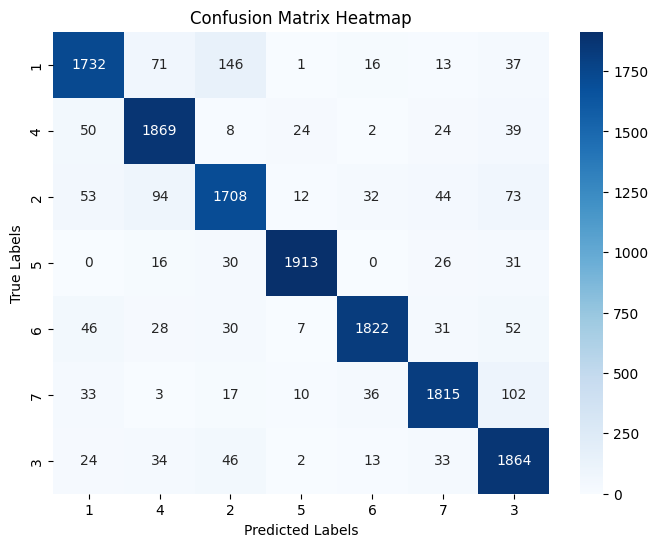

Best Parameters: {'max_depth': 20, 'n_estimators': 50}
Accuracy: 90.15731292517006 %
Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.86      0.88      2016
           2       0.88      0.93      0.90      2016
           3       0.86      0.85      0.85      2016
           4       0.97      0.95      0.96      2016
           5       0.95      0.90      0.93      2016
           6       0.91      0.90      0.91      2016
           7       0.85      0.92      0.88      2016

    accuracy                           0.90     14112
   macro avg       0.90      0.90      0.90     14112
weighted avg       0.90      0.90      0.90     14112



In [24]:
random_tree_model = RandomForestClassifier(random_state=42)
rfc_model = train_model(random_tree_model,param_grid,X_train,y_train,X_test,y_test)

In [26]:
with open(current_dir + "/../../models/muscle_group_classifier/rfc_muscle_group_classifier.pkl", 'wb') as f:
    print(type(rfc_model))
    pickle.dump(rfc_model, f)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [27]:
with open(current_dir + "/../../models/muscle_group_classifier/rfc_muscle_group_classifier.pkl", 'rb') as f:
    rfc_model = pickle.load(f)

**Random Forest with feature engineering**

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV] END ......................max_depth=20, n_estimators=50; total time=   3.4s
[CV] END ......................max_depth=20, n_estimators=50; total time=   3.4s
[CV] END ......................max_depth=20, n_estimators=50; total time=   3.4s


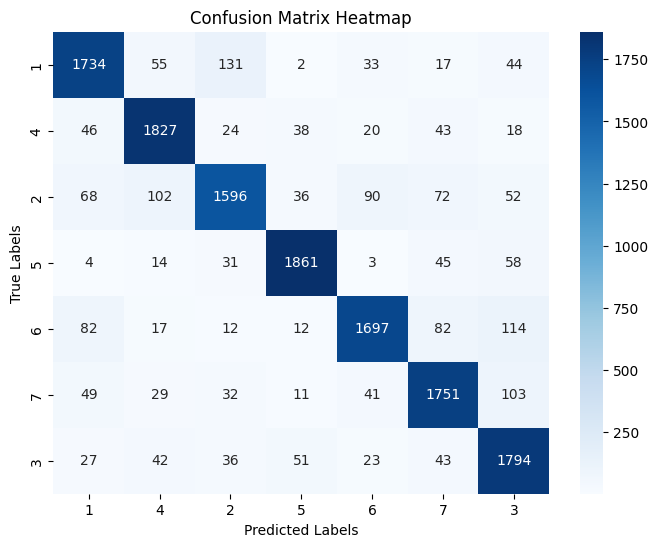

Best Parameters: {'max_depth': 20, 'n_estimators': 50}
Accuracy: 86.87641723356009 %
Classification Report:
               precision    recall  f1-score   support

           1       0.86      0.86      0.86      2016
           2       0.88      0.91      0.89      2016
           3       0.86      0.79      0.82      2016
           4       0.93      0.92      0.92      2016
           5       0.89      0.84      0.87      2016
           6       0.85      0.87      0.86      2016
           7       0.82      0.89      0.85      2016

    accuracy                           0.87     14112
   macro avg       0.87      0.87      0.87     14112
weighted avg       0.87      0.87      0.87     14112



In [28]:
rfc_feat_eng_model = train_model(random_tree_model,param_grid,X_train_feature_eng,y_train,X_test_feature_eng,y_test)

In [29]:
with open(current_dir + "/../../models/muscle_group_classifier/rfc_feat_eng_muscle_group_classifier.pkl", 'wb') as f:
    print(type(rfc_feat_eng_model))
    pickle.dump(rfc_feat_eng_model, f)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [30]:
with open(current_dir + "/../../models/muscle_group_classifier/rfc_feat_eng_muscle_group_classifier.pkl", 'rb') as f:
    rfc_feat_eng_model = pickle.load(f)

**Multilayer Perceptron**

In [31]:
param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],  
    # 'activation': ['relu', 'tanh'],  
    # 'solver': ['adam', 'sgd'],  
    # 'alpha': [0.0001, 0.001, 0.01],  
    # 'learning_rate': ['constant', 'adaptive'],  
    # 'max_iter': [200, 500, 1000]  
}

**Multilayer Perceptron with no feature engineering**

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extma

[CV] END ...........................hidden_layer_sizes=(50,); total time=   6.1s
[CV] END ...........................hidden_layer_sizes=(50,); total time=   6.2s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[CV] END ...........................hidden_layer_sizes=(50,); total time=   5.9s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.5s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.1

[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.0s
[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.0s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


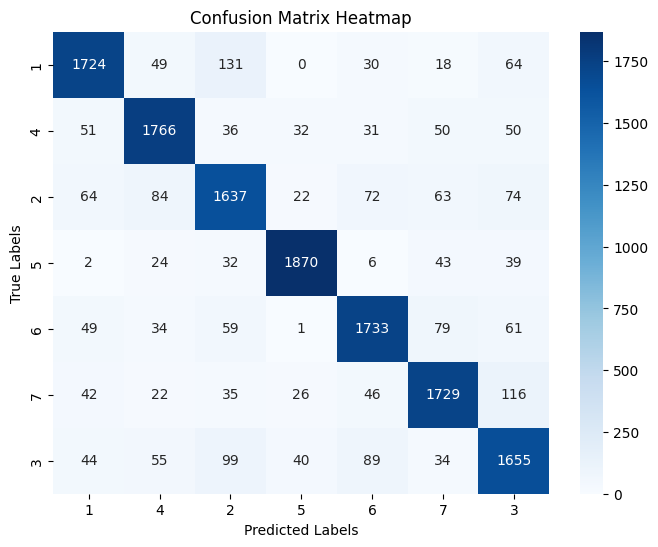

Best Parameters: {'hidden_layer_sizes': (100,)}
Accuracy: 85.84183673469387 %
Classification Report:
               precision    recall  f1-score   support

           1       0.87      0.86      0.86      2016
           2       0.87      0.88      0.87      2016
           3       0.81      0.81      0.81      2016
           4       0.94      0.93      0.93      2016
           5       0.86      0.86      0.86      2016
           6       0.86      0.86      0.86      2016
           7       0.80      0.82      0.81      2016

    accuracy                           0.86     14112
   macro avg       0.86      0.86      0.86     14112
weighted avg       0.86      0.86      0.86     14112



In [32]:
mlp_model = MLPClassifier(random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

mlp_model = train_model(mlp_model,param_grid,X_train_scaled,y_train,X_test_scaled,y_test)

In [33]:
with open(current_dir + "/../../models/muscle_group_classifier/mlp_muscle_group_classifier.pkl", 'wb') as f:
    print(type(mlp_model))
    pickle.dump(mlp_model, f)

<class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>


In [34]:
with open(current_dir + "/../../models/muscle_group_classifier/mlp_muscle_group_classifier.pkl", 'rb') as f:
    mlp_model = pickle.load(f)

**Multilayer Perceptron with feature engineering**

/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extma

Fitting 3 folds for each of 2 candidates, totalling 6 fits


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul

[CV] END ...........................hidden_layer_sizes=(50,); total time=   6.9s
[CV] END ...........................hidden_layer_sizes=(50,); total time=   7.0s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


[CV] END ...........................hidden_layer_sizes=(50,); total time=   6.6s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.1

[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.6s
[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.6s
[CV] END ..........................hidden_layer_sizes=(100,); total time=   8.7s


/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul

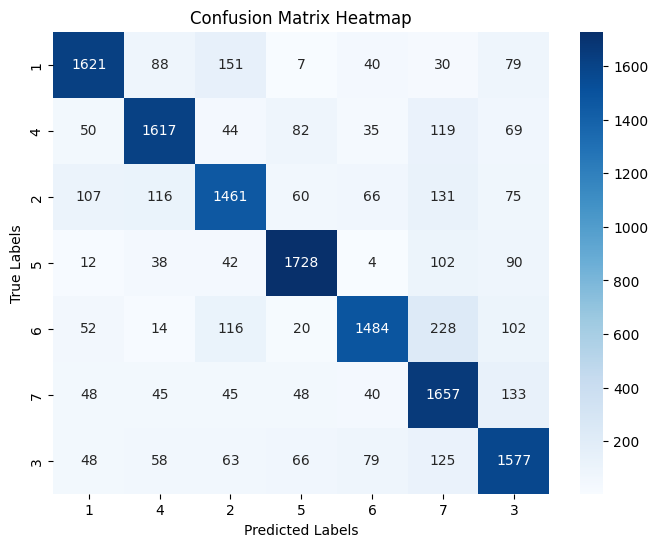

Best Parameters: {'hidden_layer_sizes': (100,)}
Accuracy: 78.97534013605441 %
Classification Report:
               precision    recall  f1-score   support

           1       0.84      0.80      0.82      2016
           2       0.82      0.80      0.81      2016
           3       0.76      0.72      0.74      2016
           4       0.86      0.86      0.86      2016
           5       0.85      0.74      0.79      2016
           6       0.69      0.82      0.75      2016
           7       0.74      0.78      0.76      2016

    accuracy                           0.79     14112
   macro avg       0.79      0.79      0.79     14112
weighted avg       0.79      0.79      0.79     14112



In [35]:
mlp_feat_eng_model = MLPClassifier(random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feature_eng)
X_test_scaled = scaler.fit_transform(X_test_feature_eng)

mlp_feat_eng_model = train_model(mlp_model,param_grid,X_train_scaled,y_train,X_test_scaled,y_test)

In [36]:
with open(current_dir + "/../../models/muscle_group_classifier/mlp_feat_eng_muscle_group_classifier.pkl", 'wb') as f:
    print(type(mlp_feat_eng_model))
    pickle.dump(mlp_feat_eng_model, f)

<class 'sklearn.neural_network._multilayer_perceptron.MLPClassifier'>


In [37]:
with open(current_dir + "/../../models/muscle_group_classifier/mlp_feat_eng_muscle_group_classifier.pkl", 'rb') as f:
    mlp_feat_eng_model = pickle.load(f)

**Support Vector Machines**

In [38]:
param_grid = {
    'C': [0.1, 1, 10],  
    'kernel': ['linear', 'rbf'],  
    'gamma': ['scale', 'auto'],  
}

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  32.8s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  36.2s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  41.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  48.6s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  48.9s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  48.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  52.6s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  52.8s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=  53.3s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=  53.7s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  58.4s
[CV] END ......................C=0.1, gamma=auto

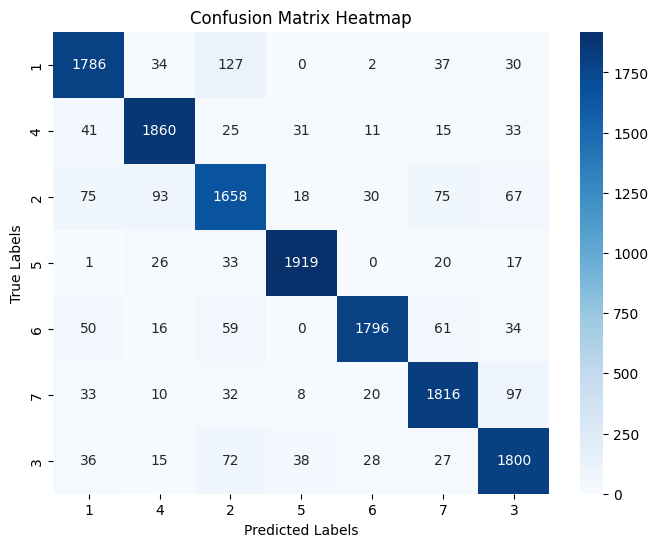

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 89.53373015873017 %
Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.89      0.88      2016
           2       0.91      0.92      0.91      2016
           3       0.83      0.82      0.82      2016
           4       0.95      0.95      0.95      2016
           5       0.95      0.89      0.92      2016
           6       0.89      0.90      0.89      2016
           7       0.87      0.89      0.88      2016

    accuracy                           0.90     14112
   macro avg       0.90      0.90      0.90     14112
weighted avg       0.90      0.90      0.90     14112



In [39]:
svc_model = SVC(random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

svc_model = train_model(svc_model,param_grid,X_train_scaled,y_train,X_test_scaled,y_test)

In [40]:
with open(current_dir + "/../../models/muscle_group_classifier/svc_muscle_group_classifier.pkl", 'wb') as f:
    print(type(svc_model))
    pickle.dump(svc_model, f)

<class 'sklearn.svm._classes.SVC'>


In [41]:
with open(current_dir + "/../../models/muscle_group_classifier/svc_muscle_group_classifier.pkl", 'rb') as f:
    svc_model = pickle.load(f)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  28.2s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  28.5s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  29.6s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  30.2s
[CV] END ...................C=0.1, gamma=auto, kernel=linear; total time=  30.5s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=  33.2s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=  37.8s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  38.1s
[CV] END ......................C=0.1, gamma=auto, kernel=rbf; total time=  41.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  41.9s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  44.7s
[CV] END ......................C=0.1, gamma=auto

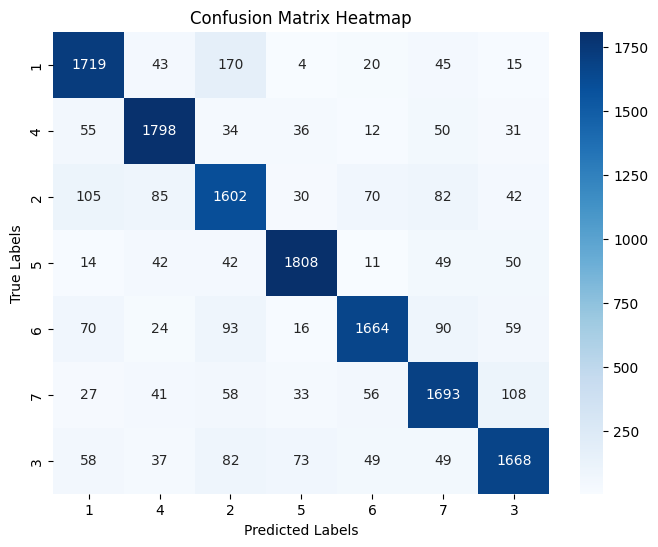

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Accuracy: 84.6938775510204 %
Classification Report:
               precision    recall  f1-score   support

           1       0.84      0.85      0.85      2016
           2       0.87      0.89      0.88      2016
           3       0.77      0.79      0.78      2016
           4       0.90      0.90      0.90      2016
           5       0.88      0.83      0.85      2016
           6       0.82      0.84      0.83      2016
           7       0.85      0.83      0.84      2016

    accuracy                           0.85     14112
   macro avg       0.85      0.85      0.85     14112
weighted avg       0.85      0.85      0.85     14112



In [42]:
svc_feat_eng_model = SVC(random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_feature_eng)
X_test_scaled = scaler.fit_transform(X_test_feature_eng)

svc_feat_eng_model = train_model(svc_model,param_grid,X_train_scaled,y_train,X_test_scaled,y_test)

In [43]:
with open(current_dir + "/../../models/muscle_group_classifier/svc_feat_eng_muscle_group_classifier.pkl", 'wb') as f:
    print(type(svc_feat_eng_model))
    pickle.dump(svc_feat_eng_model, f)

<class 'sklearn.svm._classes.SVC'>


In [44]:
with open(current_dir + "/../../models/muscle_group_classifier/svc_feat_eng_muscle_group_classifier.pkl", 'rb') as f:
    svc_feat_eng_model = pickle.load(f)